## HH 2D Testing

In [ ]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
import scipy.sparse as sp

from linear_solvers import NumPyLinearSolver, HHL
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from numerical_solvers.thomas_algorithm import numerical_solvers
from scipy.interpolate import RectBivariateSpline
from mpl_toolkits.mplot3d import Axes3D

from qiskit.quantum_info import Statevector
from qiskit import Aer, transpile
from scipy.sparse import diags
from scipy.fft import dst, idst
import matplotlib.pyplot as plt
import seaborn as sns

Utility

In [227]:
def normalize(arr, t_min, t_max):
    """
    Normalize an array to a specified range [t_min, t_max].
    
    For data that spans both negative and positive values, this function
    uses a symmetric normalization (dividing by the maximum absolute value)
    to preserve the zero-crossing and the relative oscillatory behavior.
    
    For data that does not span both signs, it uses standard min-max normalization.
    Note: The implementation uses symmetric normalization consistently,
    scaling the entire array by its maximum absolute value.
    """
    arr = np.array(arr)
    # Use symmetric normalization over the entire array
    max_abs = np.max(np.abs(arr))
    # Avoid division by zero
    if max_abs < 1e-12:
        norm_arr = arr.copy()
    else:
        norm_arr = arr / max_abs
    # If target range is [-1, 1], return the normalized array directly
    if t_min == -1 and t_max == 1:
        return norm_arr
    else:
        # Map from [-1, 1] to [t_min, t_max] element-wise
        return ((norm_arr + 1) / 2) * (t_max - t_min) + t_min
    
def get_solution_vector(solution, N, vector):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    start = 2**(N-1)
    fin = 2**(N-1) + len(vector)
    solution_vector = Statevector(solution.state).data[start:fin].real
    norm = solution.euclidean_norm
    return norm*solution_vector / np.linalg.norm(solution_vector)

def construct_TT_matrix(main_diag, off_diag, size):
    '''
    Construct a tridiagonal Toeplitz matrix using the main diagonal and off-diagonal elements.
    '''
    matrix = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], shape=(size, size)).toarray()
    return matrix

def solve_1DHHL(matrix, vector, qubits, epsilon=0.01):
    '''
    Solves the 1D HHL
    '''
    a = matrix[0, 0]
    b = matrix[0, 1]
    
    tridi_mat = TridiagonalToeplitz(qubits, a, b)
    hhl_solver = HHL(epsilon=epsilon)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, vector)
    hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector)
    #hhl_vector = np.concatenate(([0], hhl_interior, [0]))
    #hhl_sol = normalize(hhl_vector, -1.0, 1.0)
    #print('computed hhl solution\n', hhl_sol)
    return hhl_interior

def solve_1DThomas(matrix, vector):
    '''
    Solves the 1D Thomas algorithm
    '''
    
    # Compare to thomas
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix, vector)
    #num_solution = np.concatenate(([0], num_solution, [0]))
    #num_solution = normalize(num_solution, -1.0, 1.0)
    return num_solution


def visualize_solver_performance(u, thomas_u, u_reference, u_fine, Lx, Ly, N, k):
    # Grid for numerical solutions (original grid)
    x_vals = np.linspace(0, Lx, N + 2)
    y_vals = np.linspace(0, Ly, N + 2)
    X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')

    # Grid for fine solution
    N_fine = u_fine.shape[0] - 2  # Exclude boundaries
    x_fine = np.linspace(0, Lx, N_fine + 2)
    y_fine = np.linspace(0, Ly, N_fine + 2)
    X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

    # Compute error metrics
    error_standard_thomas = np.abs(u - thomas_u)
    error_standard_ref = np.abs(u - u_reference)
    error_thomas_ref = np.abs(thomas_u - u_reference)

    # 3D Surface plots
    fig = plt.figure(figsize=(18, 5))

    # Standard solution
    ax1 = fig.add_subplot(131, projection='3d')
    surf1 = ax1.plot_surface(X_full, Y_full, u, cmap='hot', alpha=0.9)
    ax1.set_title('HHL Solution')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('u')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

    # Thomas solution
    ax2 = fig.add_subplot(132, projection='3d')
    surf2 = ax2.plot_surface(X_full, Y_full, thomas_u, cmap='hot', alpha=0.9)
    ax2.set_title('Thomas Solution')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('u')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

    # Reference solution (fine grid)
    ax3 = fig.add_subplot(133, projection='3d')
    surf3 = ax3.plot_surface(X_fine, Y_fine, u_fine, cmap='hot', alpha=0.9)
    ax3.set_title('Reference Solution (Fine Grid)')
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    ax3.set_zlabel('u')
    fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)

    plt.tight_layout()
    #plt.savefig(f'figures/3D_k_analytic={k}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Error contours
    fig = plt.figure(figsize=(18, 5))

    # Error: Standard vs Thomas
    plt.subplot(1, 3, 1)
    plt.title('Error: Standard vs Thomas')
    contour1 = plt.contourf(X_full, Y_full, error_standard_thomas, 20, cmap='hot')
    plt.colorbar(contour1)
    plt.xlabel('x')
    plt.ylabel('y')

    # Error: Standard vs Reference
    plt.subplot(1, 3, 2)
    plt.title('Error: Standard vs Reference')
    contour2 = plt.contourf(X_full, Y_full, error_standard_ref, 20, cmap='hot')
    plt.colorbar(contour2)
    plt.xlabel('x')
    plt.ylabel('y')

    # Error: Thomas vs Reference
    plt.subplot(1, 3, 3)
    plt.title('Error: Thomas vs Reference')
    contour3 = plt.contourf(X_full, Y_full, error_thomas_ref, 20, cmap='hot')
    plt.colorbar(contour3)
    plt.xlabel('x')
    plt.ylabel('y')

    plt.tight_layout()
    #plt.savefig(f'figures/error_contours_k={k}.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Contour plots
    plt.figure(figsize=(18, 5))
    vmin = -1.0
    vmax = 1.0

    # Standard solution contour
    plt.subplot(1, 3, 1)
    plt.title('Standard Solution')
    contour4 = plt.contourf(X_full, Y_full, u, 20, cmap='hot', vmin=vmin, vmax=vmax)
    plt.colorbar(contour4)
    plt.xlabel('x')
    plt.ylabel('y')

    # Thomas solution contour
    plt.subplot(1, 3, 2)
    plt.title('Thomas Solution')
    contour5 = plt.contourf(X_full, Y_full, thomas_u, 20, cmap='hot', vmin=vmin, vmax=vmax)
    plt.colorbar(contour5)
    plt.xlabel('x')
    plt.ylabel('y')

    # Reference solution contour
    plt.subplot(1, 3, 3)
    plt.title('Reference Solution')
    contour6 = plt.contourf(X_fine, Y_fine, u_fine, 20, cmap='hot', vmin=vmin, vmax=vmax)
    plt.colorbar(contour6)
    plt.xlabel('x')
    plt.ylabel('y')

    plt.tight_layout()
    #plt.savefig(f'figures/solution_contour_k={k}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print error statistics
    print("Performance Metrics:")
    print(f"Max error (Standard vs Thomas): {np.max(error_standard_thomas):.2e}")
    print(f"Mean error (Standard vs Thomas): {np.mean(error_standard_thomas):.2e}")
    print(f"RMSE (Standard vs Thomas): {np.sqrt(np.mean(error_standard_thomas**2)):.2e}")
    print(f"Max error (Standard vs Reference): {np.max(error_standard_ref):.2e}")
    print(f"Mean error (Standard vs Reference): {np.mean(error_standard_ref):.2e}")
    print(f"RMSE (Standard vs Reference): {np.sqrt(np.mean(error_standard_ref**2)):.2e}")
    print(f"Max error (Thomas vs Reference): {np.max(error_thomas_ref):.2e}")
    print(f"Mean error (Thomas vs Reference): {np.mean(error_thomas_ref):.2e}")
    print(f"RMSE (Thomas vs Reference): {np.sqrt(np.mean(error_thomas_ref**2)):.2e}")

   

1. Investigation

In [ ]:
def HH2D_DST(Lx, Ly, NUM_QUBITS, k):
        # Domain specifications
        N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
        N_total = N + 2    # Total grid points including boundaries

        dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
        dy = Ly / (N + 1)

        # Create full grid including boundaries
        x_vals = np.linspace(0, Lx, N_total)
        y_vals = np.linspace(0, Ly, N_total)

        # Extract interior points (excluding boundaries)
        interior_x = x_vals[1:-1]
        interior_y = y_vals[1:-1]
        interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

        # Evaluate forcing function only on the interior grid points
        f_interior = np.sin(np.pi * interior_X) * np.sin(np.pi * interior_Y)

        # First decomposition of the Laplacian
        m_modes = np.arange(1, N+1)
        # Compute the eigenvalues of the y - Laplacian
        lambda_y = -4 / dy**2 * np.sin(m_modes * np.pi * dy / (2 * Ly))**2 

        f_hat = dst(f_interior, axis=1, type=1, norm='ortho')  # Apply DST along y

        u_hat = np.zeros((N, N))
        thomas_u_hat = np.zeros((N, N))
        print('Need to compute: ' , len(m_modes), 'modes')

        for m in range(len(m_modes)):
                if np.linalg.norm(f_hat[:, m]) < 1e-12:
                        u_hat[:, m] = 0
                        print('Skipping mode m =', m)
                        continue

                k_eff_sq = k**2 - lambda_y[m]
                print('Solving for mode m =', m)

                main_diag = -2/dx**2 + k_eff_sq
                off_diag = 1/dx**2
                A = construct_TT_matrix(main_diag, off_diag, size=N)

                print('matrix conditon number\n', np.linalg.cond(A))  

                u_hat[:, m] = solve_1DHHL(A, f_hat[:, m], NUM_QUBITS)

                # Thomas algorithm
                thomas_u_hat[:, m] = solve_1DThomas(A, f_hat[:, m])

        u = idst(u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y
        thomas_u = idst(thomas_u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y

        # add dirichlet boundary values to zero at the boundaries
        u = np.pad(u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
        u = np.pad(u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

        thomas_u = np.pad(thomas_u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
        thomas_u = np.pad(thomas_u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

        return u, thomas_u

# Example usage
Lx = 1.0
Ly = 1.0
NUM_QUBITS = 3
N = 2**NUM_QUBITS
k = 10.0
u, thomas_u = HH2D_DST(Lx, Ly, NUM_QUBITS, k)


Need to compute:  8 modes
Solving for mode m = 0
matrix conditon number
 8.484116109928577
Updated trotter steps to 5155
Updated trotter steps to 10

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Skipping mode m = 1
Skipping mode m = 2
Skipping mode m = 3
Skipping mode m = 4
Skipping mode m = 5
Skipping mode m = 6
Skipping mode m = 7


Visuals

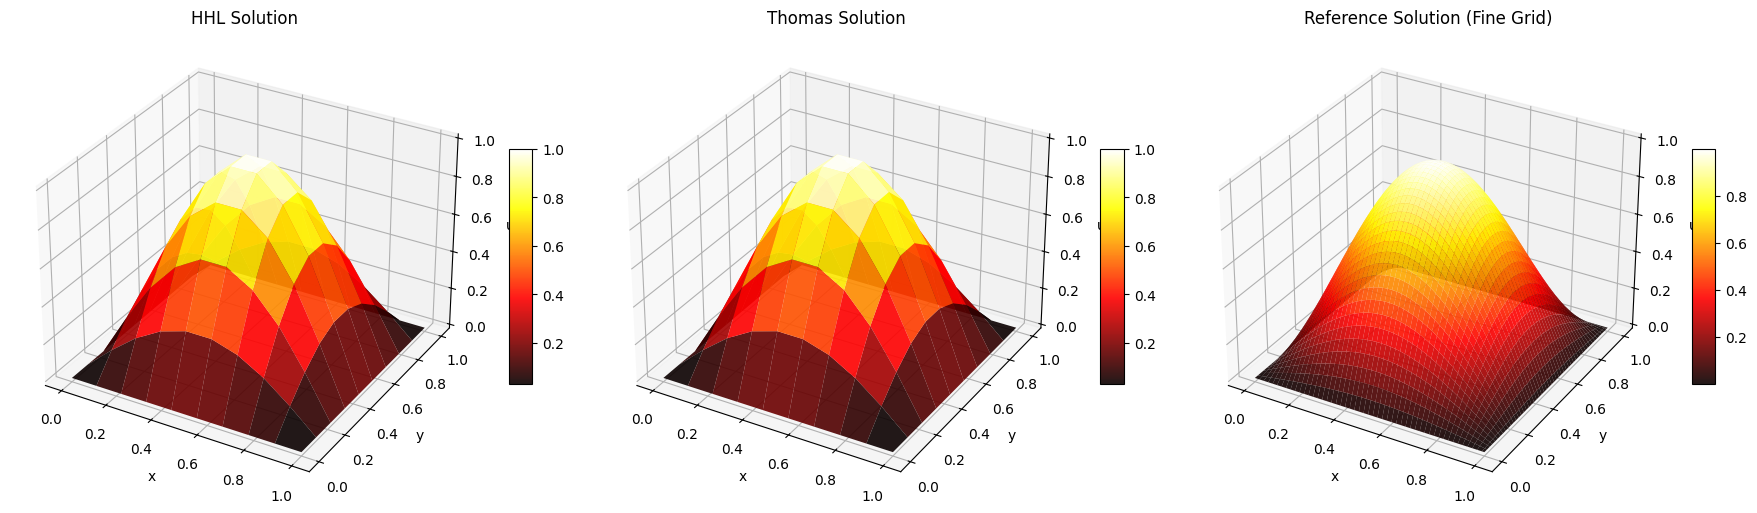

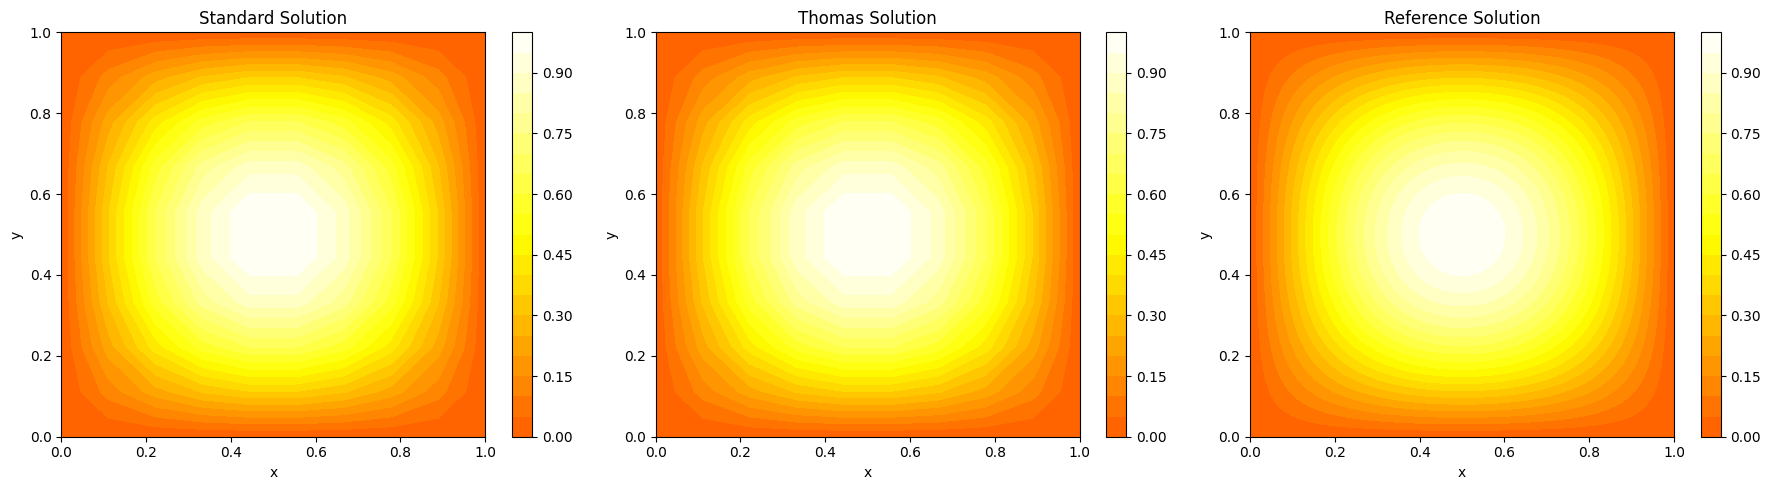

Performance Metrics:
Max error (Standard vs Thomas): 1.54e-03
Mean error (Standard vs Thomas): 3.94e-04
RMSE (Standard vs Thomas): 6.38e-04
Max error (Standard vs Reference): 1.54e-03
Mean error (Standard vs Reference): 3.94e-04
RMSE (Standard vs Reference): 6.38e-04
Max error (Thomas vs Reference): 2.94e-15
Mean error (Thomas vs Reference): 6.26e-16
RMSE (Thomas vs Reference): 1.04e-15


In [51]:

# Create grid for numerical solutions
x_vals = np.linspace(0, Lx, N+2)
y_vals = np.linspace(0, Ly, N+2)
x_high_res = np.linspace(0, Lx, 100)
X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')

# Compute the analytical solution with high resolution
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
u_analytical = -np.sin(np.pi * X_high_res) * np.sin(np.pi * Y_high_res) / (2 * np.pi**2 - k**2)
u_analytical_resampled = -np.sin(np.pi * X_full) * np.sin(np.pi * Y_full) / (2 * np.pi**2 - k**2)

u_analytical_resampled = normalize(u_analytical_resampled, -1.0, 1.0)
u_analytical = normalize(u_analytical, -1.0, 1.0)
u = normalize(u, -1.0, 1.0)
thomas_u = normalize(thomas_u, -1.0, 1.0)



visualize_solver_performance(u, thomas_u,u_analytical_resampled, u_analytical,Lx, Ly, N, k)

Investigating whether possible to solve the entire 2D system directly

## Step Function Testing on Different Wave Numbers

Shape of A: (16, 16)
matrix conditon number
 11.716662991648745
(16,)


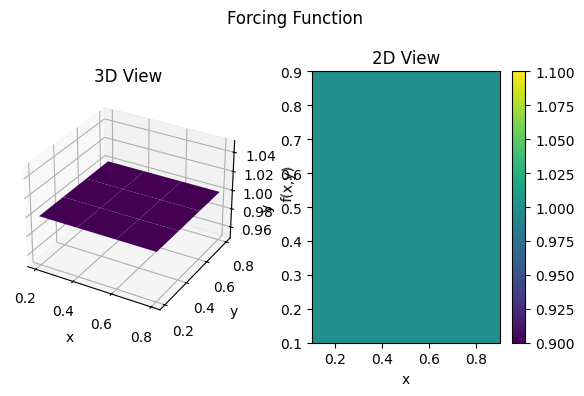

(16,)

 Number of ancilla qubits 
:  0

 Number of flag qubits 
:  1

 Number of clock qubits 
:  6

 Number of b qubits 
:  4


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (2,2)  and requested shape (1,2)

In [ ]:
def construct_helmholtz_operator(Nx, Ny, Lx, Ly, k):
    """
    Constructs the sparse matrix operator A for the 2D Helmholtz equation:
        ∇²u + k^2 u = f
    on a rectangular domain with Dirichlet boundary conditions using finite differences.
    
    Parameters:
        Nx, Ny : int
            Number of interior grid points in the x and y directions.
        Lx, Ly : float
            Domain lengths in x and y.
        k : float
            Wave number.
    
    Returns:
        A : scipy.sparse.csr_matrix
            The matrix operator of size (Nx*Ny) x (Nx*Ny).
        hx, hy : float
            Grid spacings in the x and y directions.
    """
    # Compute grid spacings (assuming Nx, Ny are the number of interior points)
    hx = Lx / (Nx + 1)
    hy = Ly / (Ny + 1)
    
    # Create the 1D Laplacian in the x-direction:
    diag_x = -2.0 / hx**2 * np.ones(Nx)
    offdiag_x = 1.0 / hx**2 * np.ones(Nx - 1)
    Tx = diags([offdiag_x, diag_x, offdiag_x], offsets=[-1, 0, 1], format='csr')
    
    # Create the 1D Laplacian in the y-direction:
    diag_y = -2.0 / hy**2 * np.ones(Ny)
    offdiag_y = 1.0 / hy**2 * np.ones(Ny - 1)
    Ty = diags([offdiag_y, diag_y, offdiag_y], offsets=[-1, 0, 1], format='csr')
    
    # Identity matrices for each direction
    Ix = sp.eye(Nx, format='csr')
    Iy = sp.eye(Ny, format='csr')
    
    # Build the 2D Laplacian using the Kronecker product:
    # Lap = kron(Iy, Tx) + kron(Ty, Ix)
    Lap = sp.kron(Iy, Tx) + sp.kron(Ty, Ix)
    
    # Total number of interior points
    N_total = Nx * Ny
    I_total = sp.eye(N_total, format='csr')
    
    # Construct the Helmholtz operator A = Laplacian + k^2 * I
    A = Lap + k**2 * I_total
    
    return A, hx, hy

def generate_forcing_function(Nx, Ny, Lx, Ly, forcing_type='uniform', **kwargs):
    """
    Generates a forcing function (RHS) for the 2D Helmholtz equation.
    
    Parameters:
        Nx, Ny : int
            Number of interior grid points in the x and y directions.
        Lx, Ly : float
            Domain lengths in x and y.
        forcing_type : str
            Type of forcing function to generate:
            - 'uniform': Constant value across domain
            - 'point_source': Point source at specified location
            - 'gaussian': Gaussian source
            - 'sinusoidal': Sinusoidal pattern
            - 'manufactured': Manufactured solution (for verification)
            - 'custom': Custom function provided as lambda
        **kwargs : dict
            Additional parameters for specific forcing types:
            - 'uniform': value (default=1.0)
            - 'point_source': x0, y0 (position), amplitude (default=1.0)
            - 'gaussian': x0, y0 (center), sigma (width), amplitude (default=1.0)
            - 'sinusoidal': kx, ky (wave numbers), amplitude (default=1.0)
            - 'manufactured': k (wave number from Helmholtz operator)
            - 'custom': func (lambda function taking x, y arrays)
    
    Returns:
        f : numpy.ndarray
            The forcing function as a flattened array of shape (Nx*Ny,).
        f_grid : numpy.ndarray
            The forcing function as a 2D grid of shape (Ny, Nx).
        x_grid, y_grid : numpy.ndarray
            Meshgrid of x and y coordinates.
    """
    # Compute grid spacings and coordinates
    hx = Lx / (Nx + 1)
    hy = Ly / (Ny + 1)
    
    # Create interior grid points
    x = np.linspace(hx, Lx - hx, Nx)
    y = np.linspace(hy, Ly - hy, Ny)
    x_grid, y_grid = np.meshgrid(x, y)
    
    # Initialize forcing function grid
    f_grid = np.zeros((Ny, Nx))
    
    # Generate forcing function based on type
    if forcing_type == 'uniform':
        value = kwargs.get('value', 1.0)
        f_grid = np.ones((Ny, Nx)) * value
        
    elif forcing_type == 'point_source':
        x0 = kwargs.get('x0', Lx/2)
        y0 = kwargs.get('y0', Ly/2)
        amplitude = kwargs.get('amplitude', 1.0)
        
        # Find closest grid point
        idx_x = np.argmin(np.abs(x - x0))
        idx_y = np.argmin(np.abs(y - y0))
        f_grid[idx_y, idx_x] = amplitude
        
    elif forcing_type == 'gaussian':
        x0 = kwargs.get('x0', Lx/2)
        y0 = kwargs.get('y0', Ly/2)
        sigma = kwargs.get('sigma', min(Lx, Ly)/8)
        amplitude = kwargs.get('amplitude', 1.0)
        
        f_grid = amplitude * np.exp(-((x_grid - x0)**2 + (y_grid - y0)**2) / (2 * sigma**2))
        
    elif forcing_type == 'sinusoidal':
        kx = kwargs.get('kx', np.pi/Lx)
        ky = kwargs.get('ky', np.pi/Ly)
        amplitude = kwargs.get('amplitude', 1.0)
        
        f_grid = amplitude * np.sin(kx * x_grid) * np.sin(ky * y_grid)
        
    elif forcing_type == 'manufactured':
        # For method of manufactured solutions, we choose a known solution u
        # and compute f = -∇²u - k²u
        k = kwargs.get('k', 1.0)
        
        # Define a known analytic solution that satisfies boundary conditions
        u_exact = np.sin(np.pi * x_grid / Lx) * np.sin(np.pi * y_grid / Ly)
        
        # Compute second derivatives for the Laplacian
        d2u_dx2 = -(np.pi/Lx)**2 * u_exact
        d2u_dy2 = -(np.pi/Ly)**2 * u_exact
        
        # Compute f = -∇²u - k²u
        f_grid = -(d2u_dx2 + d2u_dy2) - k**2 * u_exact
        
    elif forcing_type == 'custom':
        func = kwargs.get('func', lambda x, y: np.zeros_like(x))
        f_grid = func(x_grid, y_grid)
    
    else:
        raise ValueError(f"Unknown forcing_type: {forcing_type}")
    
    # Flatten the grid to match the format expected by the solver
    f = f_grid.flatten()
    
    return f, f_grid, x_grid, y_grid

def plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function"):
    """
    Plot the 2D forcing function.
    
    Parameters:
        f_grid : numpy.ndarray
            The forcing function as a 2D grid.
        x_grid, y_grid : numpy.ndarray
            Meshgrid of x and y coordinates.
        title : str
            Plot title.
    """
    plt.figure(figsize=(6, 4))
    
    # Surface plot
    ax1 = plt.subplot(121, projection='3d')
    surf = ax1.plot_surface(x_grid, y_grid, f_grid, cmap='viridis')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('f(x,y)')
    ax1.set_title('3D View')
    
    # 2D heatmap
    ax2 = plt.subplot(122)
    im = ax2.pcolormesh(x_grid, y_grid, f_grid, cmap='viridis', shading='auto')
    plt.colorbar(im, ax=ax2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('2D View')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def HH2D_DST(Lx, Ly, NUM_QUBITS, k, f_interior=None):
    """
    Solves the 2D Helmholtz equation using DST method with a custom forcing function.
    
    Parameters:
        Lx, Ly : float
            Domain lengths in x and y.
        NUM_QUBITS : int
            Number of qubits determining grid resolution.
        k : float
            Wave number for the Helmholtz equation.
        f_interior : numpy.ndarray, optional
            The forcing function on interior points as a 2D array with shape (N, N).
            If None, uses default sin(πx)sin(πy) forcing.
    
    Returns:
        u : numpy.ndarray
            Solution including boundary values, solved using HHL.
        thomas_u : numpy.ndarray
            Solution including boundary values, solved using Thomas algorithm.
    """
    # Domain specifications
    N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
    N_total = N + 2    # Total grid points including boundaries

    dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
    dy = Ly / (N + 1)

    # First decomposition of the Laplacian
    m_modes = np.arange(1, N+1)
    # Compute the eigenvalues of the y - Laplacian
    lambda_y = -4 / dy**2 * np.sin(m_modes * np.pi * dy / (2 * Ly))**2 

    f_hat = dst(f_interior, axis=1, type=1, norm='ortho')  # Apply DST along y

    u_hat = np.zeros((N, N))
    thomas_u_hat = np.zeros((N, N))
    print('Need to compute: ' , len(m_modes), 'modes')

    for m in range(len(m_modes)):
            if np.linalg.norm(f_hat[:, m]) < 1e-12:
                    u_hat[:, m] = 0
                    print('Skipping mode m =', m)
                    continue

            k_eff_sq = k**2 - lambda_y[m]
            print('Solving for mode m =', m)

            main_diag = -2/dx**2 + k_eff_sq
            off_diag = 1/dx**2
            A = construct_TT_matrix(main_diag, off_diag, size=N)

            print('matrix conditon number\n', np.linalg.cond(A))  

            u_hat[:, m] = solve_1DHHL(A, f_hat[:, m], NUM_QUBITS)

            # Thomas algorithm
            thomas_u_hat[:, m] = solve_1DThomas(A, f_hat[:, m])

    u = idst(u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y
    thomas_u = idst(thomas_u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y

    # add dirichlet boundary values to zero at the boundaries
    u = np.pad(u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
    u = np.pad(u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

    thomas_u = np.pad(thomas_u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
    thomas_u = np.pad(thomas_u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

    return u, thomas_u

# Example usage:
# Define parameters
Nx = 4       # Number of interior grid points in x-direction
Ny = 4       # Number of interior grid points in y-direction
Lx = 1.0     # Domain length in x-direction
Ly = 1.0     # Domain length in y-direction
k = 2.0     # Wave number

# Construct the Helmholtz operator
A, hx, hy = construct_helmholtz_operator(Nx, Ny, Lx, Ly, k)

A = A.toarray()
print("Shape of A:", A.shape)
print('matrix conditon number\n', np.linalg.cond(A))

# Create the RHS vector
f, f_grid, x_grid, y_grid = generate_forcing_function(
    Nx, Ny, Lx, Ly, 
    forcing_type='uniform')

# Plot the forcing function
print(f.shape)
plot_forcing_function(f_grid, x_grid, y_grid)

# Solve the linear system
u_direct = np.linalg.solve(A, f)
u_direct = u_direct.reshape((Ny, Nx))
u_direct = normalize(u_direct, -1.0, 1.0)
# add padding
u_direct = 

# Try solving with the HHL
matrix = NumPyMatrix(A)
vector = f
print(vector.shape)
qubits = 4
epsilon = 0.01
hhl_solver = HHL(epsilon=epsilon)
hhl_solution_obj = hhl_solver.solve(matrix, vector)
hhl_interior = get_solution_vector(hhl_solution_obj, hhl_solution_obj.state.num_qubits, vector)
hhl_sol = normalize(hhl_interior, -1.0, 1.0)
hhl_sol = np.pad(hhl_sol, ((0, 0), (1, 1)), mode='constant', constant_values=0)
hhl_sol = np.pad(hhl_sol, ((1, 1), (0, 0)), mode='constant', constant_values=0)

# Try solving using our DST
vector = f.reshape((Nx, Ny))
# build the matrix A
print(vector.shape)
u_hat, thomas_u_hat = HH2D_DST(Lx, Ly, 2, k, f_interior=vector)
u_hat = normalize(u_hat, -1, 1)
thomas_u_hat = normalize(thomas_u_hat, -1, 1)



shape of direct solver (4, 4)
shape of the HHL (4, 4)
shape of the DST HHL (6, 6)


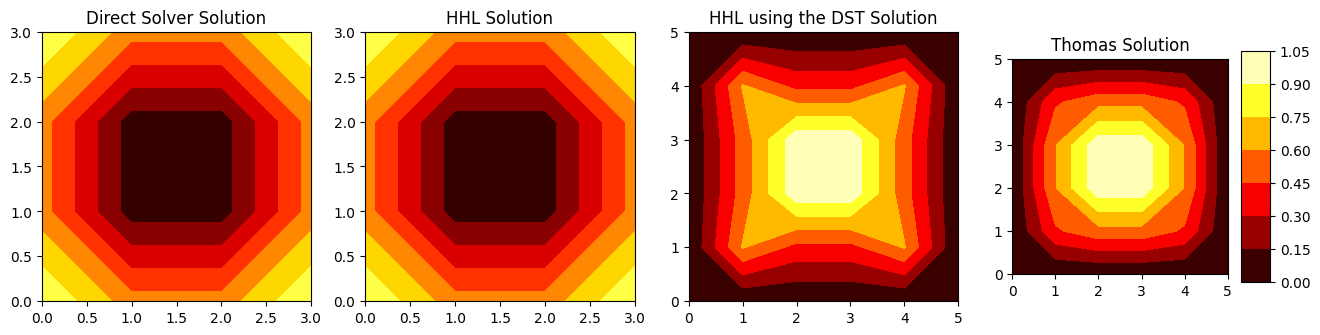

Text(0.5, 0.92, 'Thomas DST Solution')

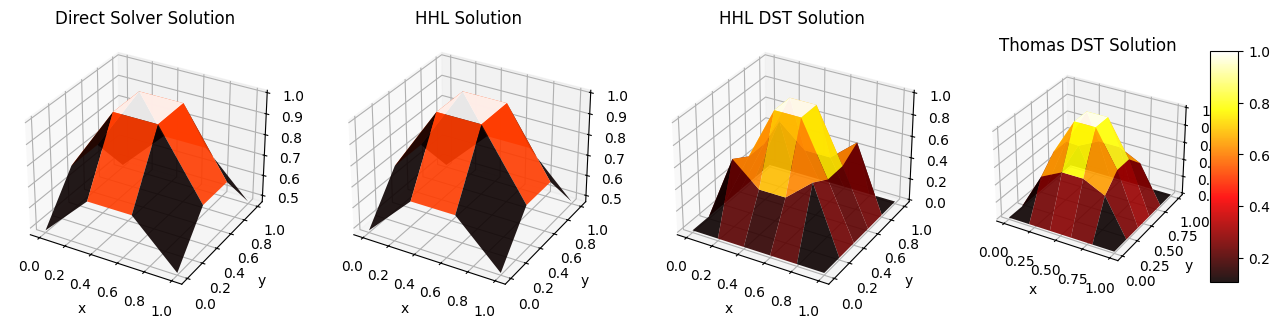

In [313]:

# Visualizatrion
# Solutions shapes
hhl_sol = hhl_sol.reshape((Ny, Nx))
print('shape of direct solver',u_direct.shape)
print('shape of the HHL', hhl_sol.shape)
print('shape of the DST HHL', u_hat.shape)

# Plot contour side by side 
fig = plt.figure(figsize=(16, 12))

plt.subplot(141, aspect='equal')
plt.contourf(u_direct, cmap='hot')
plt.title('Direct Solver Solution')
plt.subplot(142, aspect='equal')
plt.contourf(hhl_sol.reshape((Ny, Nx)), cmap='hot')
plt.title('HHL Solution')
plt.subplot(143, aspect='equal')
plt.contourf(u_hat, cmap='hot')
plt.title('HHL using the DST Solution')
plt.subplot(144, aspect = 'equal')
cont4 = plt.contourf(thomas_u_hat, cmap='hot')
plt.title('Thomas Solution')
fig.colorbar(cont4, shrink=0.25, aspect=8)
plt.show()


# plot the 3d 
fig = plt.figure(figsize=(16, 12))
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

ax = fig.add_subplot(141, projection='3d')
# color the solution
surf1 = ax.plot_surface(X, Y, -u_direct, cmap='hot', alpha = 0.9)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Direct Solver Solution')
ax = fig.add_subplot(142, projection='3d')
# color the solution
surf2 = ax.plot_surface(X, Y, -hhl_sol.reshape((Ny, Nx)), cmap='hot', alpha = 0.9)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('HHL Solution')
# Generate new grid for DST
x = np.linspace(0, Lx, len(u_hat))
y = np.linspace(0, Ly, len(u_hat[0]))
X, Y = np.meshgrid(x, y)
ax = fig.add_subplot(143, projection='3d')
surf3 = ax.plot_surface(X, Y, u_hat, cmap = 'hot', alpha = 0.9)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('HHL DST Solution')
ax = fig.add_subplot(144, projection='3d')
surf4 = ax.plot_surface(X, Y, thomas_u_hat, cmap = 'hot', alpha = 0.9)
ax.set_xlabel('x')
ax.set_ylabel('y')
fig.colorbar(surf4, ax=ax, shrink=0.25, aspect=8)
ax.set_title('Thomas DST Solution')

In [9]:
def HH2D_DST_step(Lx, Ly, NUM_QUBITS, k):
    # Domain specifications
    N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
    N_total = N + 2    # Total grid points including boundaries

    dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
    dy = Ly / (N + 1)

    # Create full grid including boundaries
    x_vals = np.linspace(0, Lx, N_total)
    y_vals = np.linspace(0, Ly, N_total)

    # Extract interior points (excluding boundaries)
    interior_x = x_vals[1:-1]
    interior_y = y_vals[1:-1]
    interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

    # Evaluate forcing function only on the interior grid points as an impulse
    f_interior = np.zeros((N, N))
    center_i = N // 2
    center_j = N // 2
    f_interior[center_i, center_j] = 1

    # First decomposition of the Laplacian
    m_modes = np.arange(1, N+1)
    # Compute the eigenvalues of the y - Laplacian
    lambda_y = -4 / dy**2 * np.sin(m_modes * np.pi * dy / (2 * Ly))**2 

    f_hat = dst(f_interior, axis=1, type=1, norm='ortho')  # Apply DST along y

    u_hat = np.zeros((N, N))
    thomas_u_hat = np.zeros((N, N))
    print('Need to compute: ', len(m_modes), 'modes')

    for m in range(len(m_modes)):
        if np.linalg.norm(f_hat[:, m]) < 1e-12:
            u_hat[:, m] = 0
            print('Skipping mode m =', m)
            continue

        k_eff_sq = k**2 - lambda_y[m]
        print('Solving for mode m =', m)

        main_diag = -2/dx**2 + k_eff_sq
        off_diag = 1/dx**2
        A = construct_TT_matrix(main_diag, off_diag, size=N)

        print('matrix condition number\n', np.linalg.cond(A))  

        u_hat[:, m] = solve_1DHHL(A, f_hat[:, m], NUM_QUBITS)

        # Thomas algorithm
        thomas_u_hat[:, m] = solve_1DThomas(A, f_hat[:, m])

    u = idst(u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y
    thomas_u = idst(thomas_u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y

    # Add Dirichlet boundary values (zero at the boundaries)
    u = np.pad(u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
    u = np.pad(u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

    thomas_u = np.pad(thomas_u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
    thomas_u = np.pad(thomas_u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

    return u, thomas_u


def HH2D_DST_Gauss(Lx, Ly, NUM_QUBITS, k):
    # Domain specifications
    N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
    N_total = N + 2    # Total grid points including boundaries

    dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
    dy = Ly / (N + 1)

    # Create full grid including boundaries
    x_vals = np.linspace(0, Lx, N_total)
    y_vals = np.linspace(0, Ly, N_total)

    # Extract interior points (excluding boundaries)
    interior_x = x_vals[1:-1]
    interior_y = y_vals[1:-1]
    interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

    # Evaluate forcing function only on the interior grid points as an impulse
    f_interior = np.zeros((N, N))
    sigma = 0.1  # or any value that suits your problem
    f_interior = np.exp(-((interior_X - Lx/2)**2 + (interior_Y - Ly/2)**2) / (2 * sigma**2))

    # First decomposition of the Laplacian
    m_modes = np.arange(1, N+1)
    # Compute the eigenvalues of the y - Laplacian
    lambda_y = -4 / dy**2 * np.sin(m_modes * np.pi * dy / (2 * Ly))**2 

    f_hat = dst(f_interior, axis=1, type=1, norm='ortho')  # Apply DST along y

    u_hat = np.zeros((N, N))
    thomas_u_hat = np.zeros((N, N))
    print('Need to compute: ', len(m_modes), 'modes')

    for m in range(len(m_modes)):
        if np.linalg.norm(f_hat[:, m]) < 1e-12:
            u_hat[:, m] = 0
            print('Skipping mode m =', m)
            continue

        k_eff_sq = k**2 - lambda_y[m]
        print('Solving for mode m =', m)

        main_diag = -2/dx**2 + k_eff_sq
        off_diag = 1/dx**2
        A = construct_TT_matrix(main_diag, off_diag, size=N)

        print('matrix condition number\n', np.linalg.cond(A))  

        u_hat[:, m] = solve_1DHHL(A, f_hat[:, m], NUM_QUBITS)

        # Thomas algorithm
        thomas_u_hat[:, m] = solve_1DThomas(A, f_hat[:, m])

    u = idst(u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y
    thomas_u = idst(thomas_u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y

    # Add Dirichlet boundary values (zero at the boundaries)
    u = np.pad(u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
    u = np.pad(u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

    thomas_u = np.pad(thomas_u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
    thomas_u = np.pad(thomas_u, ((1, 1), (0, 0)), mode='constant', constant_values=0)

    return u, thomas_u


def HH2D_analy(Lx, Ly, NUM_QUBITS, k, offset=2):
    # Original grid parameters
    N = 2**NUM_QUBITS
    N_total = N + 2
    dx = Lx / (N + 1)
    dy = Ly / (N + 1)

    # Finer grid parameters
    N_fine = 2**(NUM_QUBITS + offset)  # Larger power of two for refinement
    N_total_fine = N_fine + 2  # Include boundaries
    dx_fine = Lx / (N_fine + 1)
    dy_fine = Ly / (N_fine + 1)

    # Finer grid coordinates
    x_vals_fine = np.linspace(0, Lx, N_total_fine)
    y_vals_fine = np.linspace(0, Ly, N_total_fine)
    interior_x_fine = x_vals_fine[1:-1]
    interior_y_fine = y_vals_fine[1:-1]
    interior_X, interior_Y = np.meshgrid(interior_x_fine, interior_y_fine, indexing='ij')


    # Forcing function on finer grid (impulse at center)
    f_interior_fine = np.zeros((N_fine, N_fine))
    sigma = 0.1  # or any value that suits your problem
    f_interior_fine = np.exp(-((interior_X - Lx/2)**2 + (interior_Y - Ly/2)**2) / (2 * sigma**2))


    # Eigenvalues for finer grid
    m_modes_fine = np.arange(1, N_fine + 1)
    lambda_y_fine = -4 / dy_fine**2 * np.sin(m_modes_fine * np.pi * dy_fine / (2 * Ly))**2

    # DST along y-direction
    f_hat_fine = dst(f_interior_fine, axis=1, type=1, norm='ortho')

    # Solve using Thomas algorithm for each mode
    thomas_u_hat_fine = np.zeros((N_fine, N_fine))
    for m in range(N_fine):
        if np.linalg.norm(f_hat_fine[:, m]) < 1e-12:
            thomas_u_hat_fine[:, m] = 0
            continue
        k_eff_sq = k**2 - lambda_y_fine[m]
        main_diag = -2 / dx_fine**2 + k_eff_sq
        off_diag = 1 / dx_fine**2
        A = construct_TT_matrix(main_diag, off_diag, size=N_fine)
        thomas_u_hat_fine[:, m] = solve_1DThomas(A, f_hat_fine[:, m])

    # Inverse DST along y-direction
    thomas_u_fine = idst(thomas_u_hat_fine, axis=1, type=1, norm='ortho')

    # Pad with boundary conditions
    thomas_u_fine_padded = np.pad(thomas_u_fine, ((1, 1), (1, 1)), mode='constant', constant_values=0)

    # Interpolate to original grid
    x_original = np.linspace(0, Lx, N_total)
    y_original = np.linspace(0, Ly, N_total)
    interpolator = RectBivariateSpline(x_vals_fine, y_vals_fine, thomas_u_fine_padded)
    thomas_u_interpolated = interpolator(x_original, y_original)

    return thomas_u_fine_padded, thomas_u_interpolated

Tried to implement the chebyshev stuff but pointless

In [43]:
def cheb_diff_matrix(n):
    """Compute the Chebyshev differentiation matrix."""
    x = np.cos(np.pi * np.arange(n) / (n-1))
    c = np.ones(n)
    c[0], c[-1] = 2, 2
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                D[i, j] = (c[i] / c[j]) * (-1)**(i+j) / (x[i] - x[j])
        D[i, i] -= np.sum(D[i, :])
    return D

def HH2D_Chebyshev_Gauss(Lx, Ly, NUM_QUBITS, k):
    """
    Solve a 2D Helmholtz-like problem
         u_xx + u_yy + k^2 u = f
    using a Chebyshev spectral method in y and a uniform finite-difference discretization in x.
    
    Dirichlet boundary conditions (u=0 on the boundary) are enforced.
    
    Parameters:
      Lx, Ly     : Domain lengths in x and y.
      NUM_QUBITS : Determines the number of interior points, N = 2**NUM_QUBITS.
      k          : Wave number (or parameter in the PDE).
      
    Returns:
      u_full       : The solution computed via the HHL routine (applied in 1D along x).
      thomas_u_full: The solution computed via the Thomas algorithm for comparison.
    """
    # 1. Domain specifications:
    N = 2**NUM_QUBITS         # Number of interior grid points in x (finite difference)
    N_total = N + 2           # Total grid points (including boundaries)
    
    # x: Use uniform grid in [0, Lx]
    x_vals = np.linspace(0, Lx, N_total)
    interior_x = x_vals[1:-1]
    dx = Lx / (N + 1)
    
    # y: Chebyshev-Lobatto nodes in [-1,1] mapped to [0, Ly]
    cheb_nodes = np.cos(np.pi * np.arange(N_total) / (N_total - 1))  # in [-1,1]
    y_vals = 0.5 * (cheb_nodes + 1) * Ly
    interior_y = y_vals[1:-1]  # exclude boundaries for Dirichlet BC
    
    # 2. Evaluate forcing function on the interior grid:
    X_int, Y_int = np.meshgrid(interior_x, interior_y, indexing='ij')
    sigma = 0.1  # adjust as needed
    f_interior = np.exp(-((X_int - Lx/2)**2 + (Y_int - Ly/2)**2) / (2 * sigma**2))
    # f_interior has shape (N, N)
    
    # 3. Build the Chebyshev differentiation matrix in y
    D_y = cheb_diff_matrix(N_total)
    
    # Second derivative matrix in y:
    D2_y = D_y @ (D_y)
    # Restrict to interior nodes (to enforce Dirichlet BC)
    L_y_cheb = D2_y[1:-1, 1:-1]   # shape (N, N)
    L_y_cheb = 0.5 * (L_y_cheb + L_y_cheb.T)  # ensure symmetry
    
    # 4. Eigen-decompose the y–Laplacian
    # L_y_cheb * V_y = V_y * diag(lambda_y)
    lambda_y, V_y = np.linalg.eigh(L_y_cheb)
    
    # 5. Transform forcing function along y (project onto Chebyshev eigenbasis)
    # f_interior (N x N) is multiplied on the right by V_y.
    f_hat = f_interior @ (V_y)   # shape (N, N)
    
    # 6. Solve the 1D system in x for each Chebyshev mode in y:
    u_hat = np.zeros((N, N))
    thomas_u_hat = np.zeros((N, N))
    print('Solving for', N, 'y–modes (Chebyshev eigenbasis)')
    for m in range(N):
        # Check if forcing in this mode is negligible
        if np.linalg.norm(f_hat[:, m]) < 1e-12:
            u_hat[:, m] = 0
            thomas_u_hat[:, m] = 0
            print('Skipping mode m =', m)
            continue
        # Effective parameter for mode m (note: similar to DST version)
        k_eff_sq = k**2 - lambda_y[m]
        # Construct finite-difference matrix in x (Toeplitz form)
        main_diag = -2/dx**2 + k_eff_sq
        off_diag = 1/dx**2
        A = construct_TT_matrix(main_diag, off_diag, size=N)
        print(f"Mode m = {m}: matrix condition number = {np.linalg.cond(A):.2e}")
        # Solve using HHL simulation:
        u_hat[:, m] = solve_1DHHL(A, f_hat[:, m], NUM_QUBITS)
        # Solve classically using the Thomas algorithm:
        thomas_u_hat[:, m] = solve_1DThomas(A, f_hat[:, m])
    
    # 7. Inverse transform along y:
    # Recover the interior solution in physical space by transforming back with V_y^T.
    u_interior = u_hat.dot(V_y.T)
    thomas_u_interior = thomas_u_hat.dot(V_y.T)
    
    # 8. Pad with boundaries (which are Dirichlet: u=0)
    u_full = np.pad(u_interior, ((1, 1), (1, 1)), mode='constant', constant_values=0)
    thomas_u_full = np.pad(thomas_u_interior, ((1, 1), (1, 1)), mode='constant', constant_values=0)
    
    return u_full, thomas_u_full, x_vals, y_vals


Using DST + jacobi line search

In [ ]:

def compute_operator_u(u, dx, dy, k):
    """
    Compute the Helmholtz operator applied to u: (∇²u + k^2 u).
    Here, we use a standard 5-point stencil.
    
    Alternatively, if you have TT matrices for x and y, you could
    compute A*u using a Kronecker product formulation.
    """
    U_pad = np.pad(u, pad_width=1, mode='constant', constant_values=0)
    lap = ((U_pad[2:, 1:-1] - 2 * U_pad[1:-1, 1:-1] + U_pad[:-2, 1:-1]) / dx**2 +
           (U_pad[1:-1, 2:] - 2 * U_pad[1:-1, 1:-1] + U_pad[1:-1, :-2]) / dy**2)
    return lap + k**2 * u

def jacobi_line_search(u, f, k, dx, dy, damping=0.5):
    """
    Perform one Jacobi line search step with damping.
    
    Parameters:
      u      : 2D array, current approximate solution (interior grid)
      f      : 2D array, forcing function (interior grid)
      k      : Helmholtz parameter
      dx, dy : grid spacings
      damping: factor in (0,1] to scale the step size
    
    Returns:
      u_new   : updated solution after one line search step
      res_norm: L2 norm of the residual r = f - A(u)
    """
    # Compute the current residual: r = f - A(u)
    Au = compute_operator_u(u, dx, dy, k)
    r = f - Au
    
    # Compute Ar = A(r)
    Ar = compute_operator_u(r, dx, dy, k)
    
    num = np.sum(r * r)
    den = np.sum(r * Ar)
    
    if np.abs(den) < 1e-12:
        alpha = 0.0
    else:
        alpha = num / den
    
    # Apply damping to prevent overshooting
    alpha *= damping

    # Update solution: new solution is the old solution plus a fraction alpha of the residual.
    u_new = u + alpha * r
    res_norm = np.linalg.norm(r)
    return u_new, res_norm

def jacobi_line_iteration(u, f, k, dx, dy, tol=1e-3, max_iter=200, damping=0.01):
    """
    Perform iterative Jacobi line search until the residual norm is below tol.
    
    Parameters:
      u       : 2D array, initial approximate solution (interior grid)
      f       : 2D array, forcing function (interior grid)
      k       : Helmholtz parameter
      dx, dy  : grid spacings
      tol     : tolerance for the residual norm
      max_iter: maximum number of iterations
      damping : damping factor for the line search step size
    
    Returns:
      u       : refined solution after iterations
    """
    for i in range(max_iter):
        u_new, res_norm = jacobi_line_search(u, f, k, dx, dy, damping)
        print(f"Iteration {i+1}: residual norm = {res_norm:.3e}")
        if res_norm < tol:
            print("Convergence achieved.")
            return u_new
        u = u_new  # update solution
    print("Maximum iterations reached; final residual norm =", res_norm)
    return u_new, res_norm

def construct_f(N_total,Lx,Ly):
    # Extract interior points (excluding boundaries)
    #build the f
    # Create full grid including boundaries
    x_vals = np.linspace(0, Lx, N_total)
    y_vals = np.linspace(0, Ly, N_total)
    
    # Extract interior points (excluding boundaries)
    interior_x = x_vals[1:-1]
    interior_y = y_vals[1:-1]
    interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

    
    f = np.zeros((N, N))
    sigma = 0.1  # or any value that suits your problem
    f = np.exp(-((interior_X - Lx/2)**2 + (interior_Y - Ly/2)**2) / (2 * sigma**2))
    return f

def HH2D_DST_JLS_Gauss(Lx, Ly, NUM_QUBITS, k):
    # Domain specifications
    N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
    N_total = N + 2    # Total grid points including boundaries

    dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
    dy = Ly / (N + 1)

    # Create full grid including boundaries
    x_vals = np.linspace(0, Lx, N_total)
    y_vals = np.linspace(0, Ly, N_total)

    # Extract interior points (excluding boundaries)
    interior_x = x_vals[1:-1]
    interior_y = y_vals[1:-1]
    interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

    # Evaluate forcing function only on the interior grid points as an impulse
    f_interior = np.zeros((N, N))
    sigma = 0.1  # or any value that suits your problem
    f_interior = np.exp(-((interior_X - Lx/2)**2 + (interior_Y - Ly/2)**2) / (2 * sigma**2))

    # First decomposition of the Laplacian
    m_modes = np.arange(1, N+1)
    # Compute the eigenvalues of the y - Laplacian
    lambda_y = -4 / dy**2 * np.sin(m_modes * np.pi * dy / (2 * Ly))**2 

    f_hat = dst(f_interior, axis=1, type=1, norm='ortho')  # Apply DST along y

    u_hat = np.zeros((N, N))
    thomas_u_hat = np.zeros((N, N))
    print('Need to compute: ', len(m_modes), 'modes')

    for m in range(len(m_modes)):
        if np.linalg.norm(f_hat[:, m]) < 1e-12:
            u_hat[:, m] = 0
            print('Skipping mode m =', m)
            continue

        k_eff_sq = k**2 - lambda_y[m]
        print('Solving for mode m =', m)

        main_diag = -2/dx**2 + k_eff_sq
        off_diag = 1/dx**2
        A = construct_TT_matrix(main_diag, off_diag, size=N)

        print('matrix condition number\n', np.linalg.cond(A))  

        u_hat[:, m] = solve_1DHHL(A, f_hat[:, m], NUM_QUBITS)

        # Thomas algorithm
        thomas_u_hat[:, m] = solve_1DThomas(A, f_hat[:, m])

    u = idst(u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y
    thomas_u = idst(thomas_u_hat, axis=1, type=1, norm='ortho')  # Apply inverse DST along y
    
    return u, thomas_u

In [207]:
# Example usage
Lx = 1.0
Ly = 1.0
NUM_QUBITS = 3
N = 2**NUM_QUBITS
N_total = N + 2    # Total grid points including boundaries
dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)
k = 10.0  # Use a scalar value for k

#u, thomas_u = HH2D_DST_step(Lx, Ly, NUM_QUBITS, k)
#u, thomas_u = HH2D_DST_Gauss(Lx, Ly, NUM_QUBITS, k)
#u_full, thomas_u_full, x_vals, y_vals = HH2D_Chebyshev_Gauss(Lx, Ly, NUM_QUBITS, k)
u_sol, thomas_u_sol = HH2D_DST_JLS_Gauss(Lx, Ly, NUM_QUBITS, k)


Need to compute:  8 modes
Solving for mode m = 0
matrix condition number
 8.484116109928577
Updated trotter steps to 5155
Updated trotter steps to 10

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  5

 Number of b qubits 
:  3
Skipping mode m = 1
Solving for mode m = 2
matrix condition number
 18.752613612037898
Updated trotter steps to 5155
Updated trotter steps to 15

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  6

 Number of b qubits 
:  3
Skipping mode m = 3
Solving for mode m = 4
matrix condition number
 69.53739319587461
Updated trotter steps to 5155
Updated trotter steps to 6

 Number of ancilla qubits 
:  2

 Number of flag qubits 
:  1

 Number of clock qubits 
:  8

 Number of b qubits 
:  3
Skipping mode m = 5
Solving for mode m = 6
matrix condition number
 5.236324832583187
Updated trotter steps to 5155
Updated trotter steps to 6

 Number of ancilla qubits 
:  2

 Number of flag qubits

In [ ]:
# Perform Jacobi line search iterations
f = construct_f(N_total,Lx,Ly)
u_jls, residual_hhl = jacobi_line_iteration(u_sol, f, k, dx, dy, tol=1e-1, max_iter=200, damping=0.001)
#thomas_u_jls, residual_thomas = jacobi_line_iteration(thomas_u_sol, f, k, dx, dy, tol=1e-3, max_iter=200, damping=0.01)

print("Residual norm (HHL):", residual_hhl)
#print("Residual norm (Thomas):", residual_thomas)


Padding

In [224]:
# Add Dirichlet boundary values (zero at the boundaries)
u = np.zeros((N_total, N_total))
thomas_u = np.zeros((N_total, N_total))
other_u = np.zeros((N_total, N_total))

u = u_jls.copy()
other_u = u_sol.copy()
thomas_u = thomas_u_sol.copy()

u = np.pad(u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
u = np.pad(u, ((1, 1), (0, 0)), mode='constant', constant_values=0)
other_u = np.pad(other_u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
other_u = np.pad(other_u, ((1, 1), (0, 0)), mode='constant', constant_values=0)
thomas_u = np.pad(thomas_u, ((0, 0), (1, 1)), mode='constant', constant_values=0)
thomas_u = np.pad(thomas_u, ((1, 1), (0, 0)), mode='constant', constant_values=0)


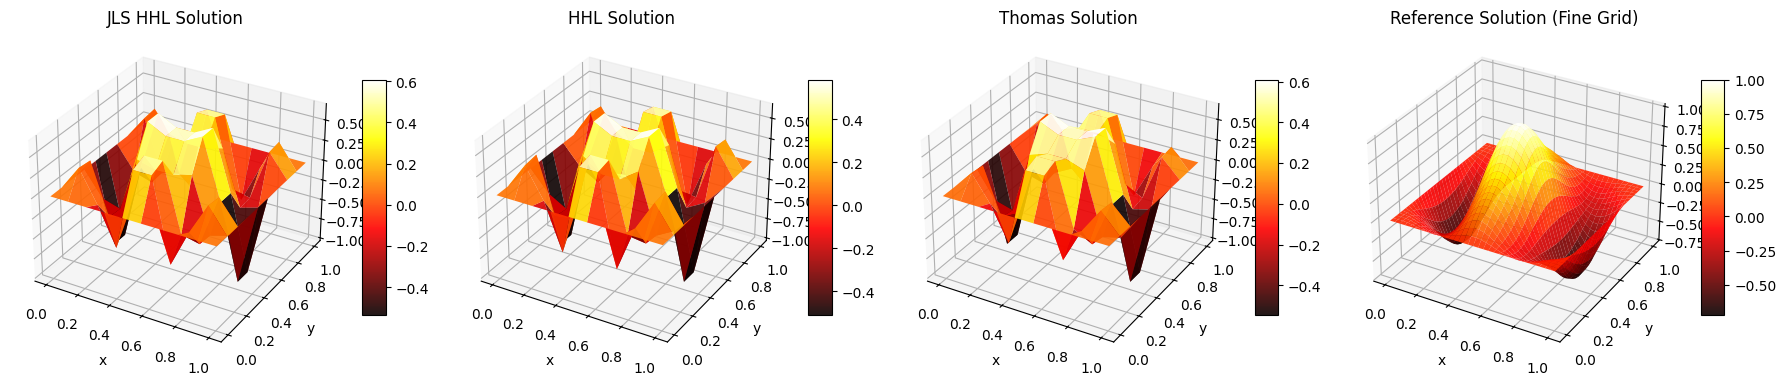

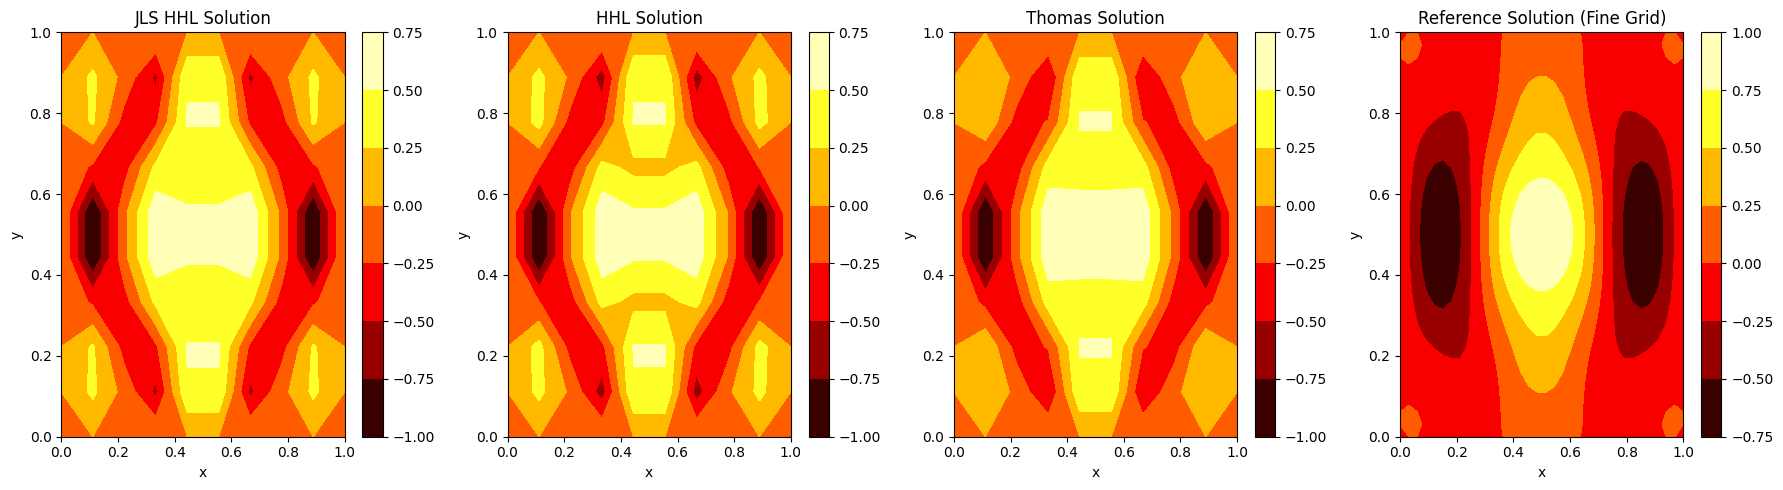

In [225]:

u_analytical, u_analytical_resampled = HH2D_analy(Lx, Ly, NUM_QUBITS, k)

# Normalize solutions for visualization
u = normalize(u, -1.0, 1.0)
thomas_u = normalize(thomas_u, -1.0, 1.0)
u_analytical = normalize(u_analytical, -1.0, 1.0)
other_u = normalize(other_u, -1.0, 1.0)

# Grid for numerical solutions (original grid)
x_vals = np.linspace(0, Lx, N + 2)
y_vals = np.linspace(0, Ly, N + 2)
X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')

# Grid for fine solution
N_fine = u_analytical.shape[0] - 2  # Exclude boundaries
x_fine = np.linspace(0, Lx, N_fine + 2)
y_fine = np.linspace(0, Ly, N_fine + 2)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# 3D Surface plots
fig = plt.figure(figsize=(18, 5))

# Standard solution
ax1 = fig.add_subplot(141, projection='3d')
surf1 = ax1.plot_surface(X_full, Y_full, u, cmap='hot', alpha=0.9)
ax1.set_title('JLS HHL Solution')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('u')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# Standard solution
ax1 = fig.add_subplot(142, projection='3d')
surf1 = ax1.plot_surface(X_full, Y_full, other_u, cmap='hot', alpha=0.9)
ax1.set_title('HHL Solution')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('u')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# Thomas solution
ax2 = fig.add_subplot(143, projection='3d')
surf2 = ax2.plot_surface(X_full, Y_full, thomas_u, cmap='hot', alpha=0.9)
ax2.set_title('Thomas Solution')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

# Reference solution (fine grid)
ax3 = fig.add_subplot(144, projection='3d')
surf3 = ax3.plot_surface(X_fine, Y_fine, u_analytical, cmap='hot', alpha=0.9)
ax3.set_title('Reference Solution (Fine Grid)')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('u')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)

plt.tight_layout()
#plt.savefig(f'figures/3D_k_analytic={k}.png', dpi=300, bbox_inches='tight')
plt.show()

# 2D Contour plots
fig = plt.figure(figsize=(18, 5))

# Standard solution
ax1 = fig.add_subplot(141)
contour1 = ax1.contourf(X_full, Y_full, u, cmap='hot')
ax1.set_title('JLS HHL Solution')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(contour1, ax=ax1)

# Standard solution
ax1 = fig.add_subplot(142)
contour1 = ax1.contourf(X_full, Y_full, other_u, cmap='hot')
ax1.set_title('HHL Solution')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
fig.colorbar(contour1, ax=ax1)

# Thomas solution
ax2 = fig.add_subplot(143)
contour2 = ax2.contourf(X_full, Y_full, thomas_u, cmap='hot')
ax2.set_title('Thomas Solution')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
fig.colorbar(contour2, ax=ax2)

# Reference solution (fine grid)
ax3 = fig.add_subplot(144)
contour3 = ax3.contourf(X_fine, Y_fine, u_analytical, cmap='hot')
ax3.set_title('Reference Solution (Fine Grid)')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
fig.colorbar(contour3, ax=ax3)

plt.tight_layout()
#plt.savefig(f'figures/2D_k_analytic={k}.png', dpi=300, bbox_inches='tight')
plt.show()

